# MDCE Model Challenger Add-on

This notebook does not rerun ingestion. It starts from `pit_training_rows.parquet` and tests whether bigger tree ensembles or a PyTorch neural network can beat the hardened bias-guard baseline.

Protocol:

- Uses `no_identity_context` feature set from the bias guard audit.
- Selects thresholds on 2022 validation.
- Reports final metrics on untouched 2023 holdout.
- Promotes the neural network only if it clearly beats tree models.


## 1. Mount Drive


In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


## 2. Install Dependencies

Torch is usually preinstalled in Colab, but this keeps the notebook self-contained.


In [2]:
%pip install -q pandas numpy pyarrow scikit-learn matplotlib seaborn joblib torch


## 3. Run Model Challenger

This trains larger RandomForest/ExtraTrees candidates and two PyTorch MLP challengers. It may take longer than the bias guard notebook.


In [3]:
from pathlib import Path
import json
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT = Path("/content/drive/MyDrive/ibm_project_stuff/MDCE")
if not ROOT.exists():
    raise FileNotFoundError(
        f"Expected project folder not found: {ROOT}. "
        "This add-on is folder-locked and will not scan MyDrive."
    )

PROCESSED_DIR = ROOT / "data" / "processed"
REPORT_DIR = ROOT / "outputs" / "reports"
CHART_DIR = ROOT / "outputs" / "charts"
MODEL_DIR = ROOT / "outputs" / "models"
for folder in [REPORT_DIR, CHART_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

training_path = PROCESSED_DIR / "pit_training_rows.parquet"
training = pd.read_parquet(training_path)
print("training shape:", training.shape)

target = "pit_within_3_laps"
numeric_features_all = [
    "lap",
    "lap_time_s",
    "position",
    "grid",
    "tyre_age",
    "stint",
    "air_temp",
    "track_temp",
    "humidity",
    "pressure",
    "rainfall",
    "wind_speed",
    "wind_direction",
    "rolling_lap_avg_3",
    "rolling_lap_avg_5",
    "lap_time_delta",
    "degradation_3",
    "degradation_5",
    "lap_progress_ratio",
]
categorical_features_all = ["tyre_compound", "driver_code", "circuit"]

# Bias guard showed no_identity_context was strongest and cleaner.
numeric_features = numeric_features_all
categorical_features = ["tyre_compound"]
feature_cols = numeric_features + categorical_features

required = feature_cols + [target, "year"]
missing = [col for col in required if col not in training.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

train_2021 = training[training["year"].eq(2021)].dropna(subset=[target]).copy()
valid_2022 = training[training["year"].eq(2022)].dropna(subset=[target]).copy()
train_2021_2022 = training[training["year"].isin([2021, 2022])].dropna(subset=[target]).copy()
test_2023 = training[training["year"].eq(2023)].dropna(subset=[target]).copy()

X_train_2021 = train_2021[feature_cols]
y_train_2021 = train_2021[target].astype(int)
X_valid_2022 = valid_2022[feature_cols]
y_valid_2022 = valid_2022[target].astype(int)
X_train_full = train_2021_2022[feature_cols]
y_train_full = train_2021_2022[target].astype(int)
X_test = test_2023[feature_cols]
y_test = test_2023[target].astype(int)

print("feature set: no_identity_context")
print("features:", feature_cols)
print("train_2021:", len(train_2021), "valid_2022:", len(valid_2022), "train_full:", len(train_2021_2022), "test_2023:", len(test_2023))


def write_json(path, obj):
    Path(path).write_text(json.dumps(obj, indent=2, default=str), encoding="utf-8")
    print("wrote:", path)


def make_onehot():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_tree_preprocess():
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
            ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
        ]
    )


def make_dense_preprocess():
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
            ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", make_onehot())]), categorical_features),
        ]
    )


def metric_row(model_name, y_true, scores, threshold):
    labels = (scores >= threshold).astype(int)
    return {
        "model": model_name,
        "threshold": float(threshold),
        "rows": int(len(y_true)),
        "positive_rate": float(np.mean(y_true)),
        "predicted_positive_rate": float(np.mean(labels)),
        "accuracy": float(accuracy_score(y_true, labels)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, labels)),
        "precision": float(precision_score(y_true, labels, zero_division=0)),
        "recall": float(recall_score(y_true, labels, zero_division=0)),
        "f1": float(f1_score(y_true, labels, zero_division=0)),
        "brier_score": float(brier_score_loss(y_true, scores)),
        "roc_auc": float(roc_auc_score(y_true, scores)) if len(set(y_true)) == 2 else None,
        "average_precision": float(average_precision_score(y_true, scores)) if len(set(y_true)) == 2 else None,
    }


def best_threshold_from_scores(y_true, scores):
    rows = []
    for threshold in np.round(np.arange(0.10, 0.91, 0.05), 2):
        rows.append(metric_row("threshold_candidate", y_true, scores, float(threshold)))
    df = pd.DataFrame(rows)
    return df.sort_values(["f1", "precision"], ascending=False).iloc[0].to_dict(), df


print("\nSTEP A: bigger tree challenger search")
tree_specs = [
    (
        "rf_500_leaf2_sqrt_balanced",
        RandomForestClassifier(n_estimators=500, min_samples_leaf=2, max_features="sqrt", class_weight="balanced", random_state=SEED, n_jobs=-1),
    ),
    (
        "rf_800_leaf3_sqrt_balanced",
        RandomForestClassifier(n_estimators=800, min_samples_leaf=3, max_features="sqrt", class_weight="balanced", random_state=SEED, n_jobs=-1),
    ),
    (
        "rf_800_leaf5_half_balanced_subsample",
        RandomForestClassifier(n_estimators=800, min_samples_leaf=5, max_features=0.5, class_weight="balanced_subsample", random_state=SEED, n_jobs=-1),
    ),
    (
        "extra_trees_600_leaf2_sqrt_balanced",
        ExtraTreesClassifier(n_estimators=600, min_samples_leaf=2, max_features="sqrt", class_weight="balanced", random_state=SEED, n_jobs=-1),
    ),
]

candidate_rows = []
threshold_sweeps = []
trained_final_models = {}

for name, estimator in tree_specs:
    print("validating:", name)
    validation_model = Pipeline([("preprocess", make_tree_preprocess()), ("classifier", estimator)])
    validation_model.fit(X_train_2021, y_train_2021)
    valid_scores = validation_model.predict_proba(X_valid_2022)[:, 1]
    best_threshold, sweep = best_threshold_from_scores(y_valid_2022.to_numpy(), valid_scores)
    sweep["candidate_model"] = name
    threshold_sweeps.append(sweep)

    final_estimator = estimator.__class__(**estimator.get_params())
    final_model = Pipeline([("preprocess", make_tree_preprocess()), ("classifier", final_estimator)])
    final_model.fit(X_train_full, y_train_full)
    test_scores = final_model.predict_proba(X_test)[:, 1]
    row = metric_row(name, y_test.to_numpy(), test_scores, best_threshold["threshold"])
    row["model_family"] = "tree_ensemble"
    row["threshold_source"] = "best_f1_on_2022_validation"
    row["validation_threshold"] = best_threshold["threshold"]
    row["validation_f1"] = best_threshold["f1"]
    row["validation_precision"] = best_threshold["precision"]
    row["validation_recall"] = best_threshold["recall"]
    candidate_rows.append(row)
    trained_final_models[name] = final_model


class MLPBinaryClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=(128, 64), dropout=0.20):
        super().__init__()
        layers = []
        previous = input_dim
        for hidden in hidden_dims:
            layers.append(nn.Linear(previous, hidden))
            layers.append(nn.BatchNorm1d(hidden))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            previous = hidden
        layers.append(nn.Linear(previous, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


def train_torch_mlp(X_train_df, y_train_series, X_valid_df, y_valid_series, model_name, epochs=45, hidden_dims=(128, 64), dropout=0.20):
    preprocess = make_dense_preprocess()
    X_train_np = preprocess.fit_transform(X_train_df).astype("float32")
    X_valid_np = preprocess.transform(X_valid_df).astype("float32")
    y_train_np = y_train_series.to_numpy(dtype="float32")
    y_valid_np = y_valid_series.to_numpy(dtype="float32")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MLPBinaryClassifier(X_train_np.shape[1], hidden_dims=hidden_dims, dropout=dropout).to(device)
    positive_weight = torch.tensor([(len(y_train_np) - y_train_np.sum()) / max(1.0, y_train_np.sum())], dtype=torch.float32).to(device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=positive_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

    train_ds = TensorDataset(torch.tensor(X_train_np), torch.tensor(y_train_np))
    valid_tensor = torch.tensor(X_valid_np).to(device)
    train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)

    best_state = None
    best_ap = -1.0
    patience = 7
    no_improve = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(float(loss.detach().cpu()))

        model.eval()
        with torch.no_grad():
            valid_scores = torch.sigmoid(model(valid_tensor)).detach().cpu().numpy()
        valid_ap = average_precision_score(y_valid_np, valid_scores)
        valid_auc = roc_auc_score(y_valid_np, valid_scores)
        history.append({"model": model_name, "epoch": epoch, "train_loss": float(np.mean(train_losses)), "valid_ap": float(valid_ap), "valid_roc_auc": float(valid_auc)})

        if valid_ap > best_ap:
            best_ap = valid_ap
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        valid_scores = torch.sigmoid(model(valid_tensor)).detach().cpu().numpy()
    return model, preprocess, valid_scores, pd.DataFrame(history)


def predict_torch_mlp(model, preprocess, X_df):
    device = next(model.parameters()).device
    X_np = preprocess.transform(X_df).astype("float32")
    tensor = torch.tensor(X_np).to(device)
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(tensor)).detach().cpu().numpy()


print("\nSTEP B: PyTorch neural-network challenger")
mlp_specs = [
    {"name": "torch_mlp_128_64_dropout20", "hidden_dims": (128, 64), "dropout": 0.20},
    {"name": "torch_mlp_256_128_dropout25", "hidden_dims": (256, 128), "dropout": 0.25},
]

all_histories = []
torch_final_artifacts = {}
for spec in mlp_specs:
    print("validating:", spec["name"])
    validation_model, validation_preprocess, valid_scores, history_df = train_torch_mlp(
        X_train_2021,
        y_train_2021,
        X_valid_2022,
        y_valid_2022,
        spec["name"],
        epochs=45,
        hidden_dims=spec["hidden_dims"],
        dropout=spec["dropout"],
    )
    all_histories.append(history_df)
    best_threshold, sweep = best_threshold_from_scores(y_valid_2022.to_numpy(), valid_scores)
    sweep["candidate_model"] = spec["name"]
    threshold_sweeps.append(sweep)

    final_model, final_preprocess, _, final_history_df = train_torch_mlp(
        X_train_full,
        y_train_full,
        X_valid_2022,
        y_valid_2022,
        spec["name"] + "_final",
        epochs=45,
        hidden_dims=spec["hidden_dims"],
        dropout=spec["dropout"],
    )
    all_histories.append(final_history_df)
    test_scores = predict_torch_mlp(final_model, final_preprocess, X_test)
    row = metric_row(spec["name"], y_test.to_numpy(), test_scores, best_threshold["threshold"])
    row["model_family"] = "pytorch_mlp"
    row["threshold_source"] = "best_f1_on_2022_validation"
    row["validation_threshold"] = best_threshold["threshold"]
    row["validation_f1"] = best_threshold["f1"]
    row["validation_precision"] = best_threshold["precision"]
    row["validation_recall"] = best_threshold["recall"]
    candidate_rows.append(row)
    torch_final_artifacts[spec["name"]] = {"model": final_model, "preprocess": final_preprocess, "hidden_dims": spec["hidden_dims"], "dropout": spec["dropout"]}

candidate_df = pd.DataFrame(candidate_rows).sort_values(["average_precision", "f1"], ascending=False)
candidate_df.to_csv(REPORT_DIR / "model_challenger_leaderboard.csv", index=False)
pd.concat(threshold_sweeps, ignore_index=True).to_csv(REPORT_DIR / "model_challenger_threshold_sweeps.csv", index=False)
if all_histories:
    pd.concat(all_histories, ignore_index=True).to_csv(REPORT_DIR / "model_challenger_torch_training_history.csv", index=False)

best = candidate_df.iloc[0].to_dict()
best_name = str(best["model"])
best_family = str(best["model_family"])
print("best challenger:", best_name, best_family)

if best_family == "tree_ensemble":
    best_path = MODEL_DIR / "pit_window_challenger_best_model.joblib"
    joblib.dump(trained_final_models[best_name], best_path)
else:
    best_path = MODEL_DIR / "pit_window_challenger_best_model.pt"
    artifact = torch_final_artifacts[best_name]
    torch.save(
        {
            "state_dict": artifact["model"].state_dict(),
            "input_dim": next(artifact["model"].parameters()).shape[1] if len(list(artifact["model"].parameters())) else None,
            "hidden_dims": artifact["hidden_dims"],
            "dropout": artifact["dropout"],
            "feature_cols": feature_cols,
            "numeric_features": numeric_features,
            "categorical_features": categorical_features,
            "threshold": best["threshold"],
        },
        best_path,
    )
    joblib.dump(artifact["preprocess"], MODEL_DIR / "pit_window_challenger_best_preprocess.joblib")

plt.figure(figsize=(10, 5))
plot_df = candidate_df.sort_values("average_precision", ascending=True)
plt.barh(plot_df["model"], plot_df["average_precision"])
plt.title("Model Challenger: 2023 Average Precision")
plt.xlabel("Average precision")
plt.tight_layout()
plt.savefig(CHART_DIR / "model_challenger_average_precision.png", dpi=160)
plt.close()

plt.figure(figsize=(10, 5))
plot_df = candidate_df.sort_values("f1", ascending=True)
plt.barh(plot_df["model"], plot_df["f1"])
plt.title("Model Challenger: 2023 F1")
plt.xlabel("F1")
plt.tight_layout()
plt.savefig(CHART_DIR / "model_challenger_f1.png", dpi=160)
plt.close()

if all_histories:
    history_all = pd.concat(all_histories, ignore_index=True)
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=history_all, x="epoch", y="valid_ap", hue="model")
    plt.title("PyTorch Challenger Training History")
    plt.ylabel("Validation average precision")
    plt.tight_layout()
    plt.savefig(CHART_DIR / "model_challenger_torch_training_history.png", dpi=160)
    plt.close()

challenger_report = {
    "feature_set": "no_identity_context",
    "selection_protocol": "Threshold chosen on 2022 validation; final metrics reported on untouched 2023 holdout.",
    "best_model": best,
    "best_model_path": str(best_path),
    "leaderboard": candidate_df.to_dict(orient="records"),
    "interpretation": [
        "A neural network challenger is promoted only if it beats tree models on holdout metrics and robustness, not because it sounds advanced.",
        "RandomForest/ExtraTrees remain strong for tabular public race data and are easier to explain.",
        "The selected model should still disclose schedule/progress dependency from the bias-guard audit.",
    ],
}
write_json(REPORT_DIR / "model_challenger_report.json", challenger_report)

lines = [
    "# MDCE Model Challenger Report",
    "",
    "## Protocol",
    "",
    "- Feature set: `no_identity_context` from the bias guard audit.",
    "- Thresholds are selected on 2022 validation.",
    "- Final scores are reported on untouched 2023 holdout.",
    "- Neural network is treated as a challenger, not automatically promoted.",
    "",
    "## Best Model",
    "",
    f"- Best model: `{best_name}`",
    f"- Model family: `{best_family}`",
    f"- Model path: `{best_path}`",
    f"- Average precision: `{best['average_precision']:.3f}`",
    f"- ROC-AUC: `{best['roc_auc']:.3f}`",
    f"- F1: `{best['f1']:.3f}`",
    f"- Precision: `{best['precision']:.3f}`",
    f"- Recall: `{best['recall']:.3f}`",
    f"- Threshold: `{best['threshold']}`",
    "",
    "## Leaderboard",
    "",
    "| Model | Family | AP | ROC-AUC | F1 | Precision | Recall | Brier | Threshold |",
    "|---|---|---:|---:|---:|---:|---:|---:|---:|",
]
for _, row in candidate_df.iterrows():
    lines.append(
        f"| {row['model']} | {row['model_family']} | {row['average_precision']:.3f} | {row['roc_auc']:.3f} | {row['f1']:.3f} | {row['precision']:.3f} | {row['recall']:.3f} | {row['brier_score']:.3f} | {row['threshold']:.2f} |"
    )

lines += [
    "",
    "## Decision Rule",
    "",
    "If the neural network does not clearly beat the tree ensemble on 2023 holdout and proof audits, keep the tree model. This is an evidence-based rejection, not a failure.",
    "",
    "## Files Written",
    "",
    f"- `{REPORT_DIR / 'model_challenger_leaderboard.csv'}`",
    f"- `{REPORT_DIR / 'model_challenger_threshold_sweeps.csv'}`",
    f"- `{REPORT_DIR / 'model_challenger_torch_training_history.csv'}`",
    f"- `{REPORT_DIR / 'model_challenger_report.json'}`",
    f"- `{CHART_DIR / 'model_challenger_average_precision.png'}`",
    f"- `{CHART_DIR / 'model_challenger_f1.png'}`",
    f"- `{CHART_DIR / 'model_challenger_torch_training_history.png'}`",
]
(REPORT_DIR / "model_challenger_report.md").write_text("\n".join(lines), encoding="utf-8")

print("\nMODEL CHALLENGER COMPLETE")
print("Best model:", best_name)
print("Best family:", best_family)
print("Best path:", best_path)
print(candidate_df.to_string(index=False))


training shape: (40867, 32)
feature set: no_identity_context
features: ['lap', 'lap_time_s', 'position', 'grid', 'tyre_age', 'stint', 'air_temp', 'track_temp', 'humidity', 'pressure', 'rainfall', 'wind_speed', 'wind_direction', 'rolling_lap_avg_3', 'rolling_lap_avg_5', 'lap_time_delta', 'degradation_3', 'degradation_5', 'lap_progress_ratio', 'tyre_compound']
train_2021: 13766 valid_2022: 12417 train_full: 26183 test_2023: 14684

STEP A: bigger tree challenger search
validating: rf_500_leaf2_sqrt_balanced
validating: rf_800_leaf3_sqrt_balanced
validating: rf_800_leaf5_half_balanced_subsample
validating: extra_trees_600_leaf2_sqrt_balanced

STEP B: PyTorch neural-network challenger
validating: torch_mlp_128_64_dropout20
validating: torch_mlp_256_128_dropout25
best challenger: rf_800_leaf5_half_balanced_subsample tree_ensemble
wrote: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/model_challenger_report.json

MODEL CHALLENGER COMPLETE
Best model: rf_800_leaf5_half_balanced_

## 4. View Outputs


/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/models/pit_window_challenger_best_model.joblib True
/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/models/pit_window_challenger_best_model.pt False


# MDCE Model Challenger Report

## Protocol

- Feature set: `no_identity_context` from the bias guard audit.
- Thresholds are selected on 2022 validation.
- Final scores are reported on untouched 2023 holdout.
- Neural network is treated as a challenger, not automatically promoted.

## Best Model

- Best model: `rf_800_leaf5_half_balanced_subsample`
- Model family: `tree_ensemble`
- Model path: `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/models/pit_window_challenger_best_model.joblib`
- Average precision: `0.820`
- ROC-AUC: `0.893`
- F1: `0.731`
- Precision: `0.874`
- Recall: `0.628`
- Threshold: `0.5`

## Leaderboard

| Model | Family | AP | ROC-AUC | F1 | Precision | Recall | Brier | Threshold |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| rf_800_leaf5_half_balanced_subsample | tree_ensemble | 0.820 | 0.893 | 0.731 | 0.874 | 0.628 | 0.084 | 0.50 |
| rf_800_leaf3_sqrt_balanced | tree_ensemble | 0.819 | 0.895 | 0.723 | 0.791 | 0.667 | 0.085 | 0.40 |
| rf_500_leaf2_sqrt_balanced | tree_ensemble | 0.817 | 0.894 | 0.725 | 0.875 | 0.620 | 0.085 | 0.45 |
| torch_mlp_128_64_dropout20 | pytorch_mlp | 0.783 | 0.877 | 0.672 | 0.664 | 0.679 | 0.150 | 0.80 |
| torch_mlp_256_128_dropout25 | pytorch_mlp | 0.768 | 0.869 | 0.655 | 0.612 | 0.704 | 0.149 | 0.70 |
| extra_trees_600_leaf2_sqrt_balanced | tree_ensemble | 0.768 | 0.869 | 0.666 | 0.685 | 0.648 | 0.108 | 0.45 |

## Decision Rule

If the neural network does not clearly beat the tree ensemble on 2023 holdout and proof audits, keep the tree model. This is an evidence-based rejection, not a failure.

## Files Written

- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/model_challenger_leaderboard.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/model_challenger_threshold_sweeps.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/model_challenger_torch_training_history.csv`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/reports/model_challenger_report.json`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/model_challenger_average_precision.png`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/model_challenger_f1.png`
- `/content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/model_challenger_torch_training_history.png`

 model_challenger_leaderboard.csv


,model,threshold,rows,positive_rate,predicted_positive_rate,accuracy,balanced_accuracy,precision,recall,f1,brier_score,roc_auc,average_precision,model_family,threshold_source,validation_threshold,validation_f1,validation_precision,validation_recall
0,rf_800_leaf5_half_balanced_subsample,0.50,14684,0.22167,0.159289,0.897439,0.801073,0.873878,0.627957,0.730783,0.083661,0.893386,0.819995,tree_ensemble,best_f1_on_2022_validation,0.50,0.714227,0.820924,0.632075
1,rf_800_leaf3_sqrt_balanced,0.40,14684,0.22167,0.186938,0.886952,0.808178,0.790528,0.666667,0.723333,0.085164,0.894588,0.819363,tree_ensemble,best_f1_on_2022_validation,0.40,0.697709,0.710843,0.685051
2,rf_500_leaf2_sqrt_balanced,0.45,14684,0.22167,0.157042,0.896009,0.797188,0.874675,0.619662,0.725409,0.084675,0.893556,0.817363,tree_ensemble,best_f1_on_2022_validation,0.45,0.693744,0.798018,0.613570
3,torch_mlp_128_64_dropout20,0.80,14684,0.22167,0.226505,0.852833,0.790655,0.664462,0.678955,0.671630,0.150246,0.876728,0.782980,pytorch_mlp,best_f1_on_2022_validation,0.80,0.539052,0.518792,0.560958
4,torch_mlp_256_128_dropout25,0.70,14684,0.22167,0.255244,0.835263,0.788376,0.611526,0.704147,0.654577,0.148557,0.869497,0.767686,pytorch_mlp,best_f1_on_2022_validation,0.70,0.517159,0.486262,0.552250
5,extra_trees_600_leaf2_sqrt_balanced,0.45,14684,0.22167,0.209820,0.855898,0.781637,0.684843,0.648233,0.666035,0.108297,0.868621,0.767571,tree_ensemble,best_f1_on_2022_validation,0.45,0.609966,0.579308,0.644049


 model_challenger_threshold_sweeps.csv


,model,threshold,rows,positive_rate,predicted_positive_rate,accuracy,balanced_accuracy,precision,recall,f1,brier_score,roc_auc,average_precision,candidate_model
0,threshold_candidate,0.10,12417,0.221954,0.784167,0.427801,0.624245,0.276677,0.977504,0.431282,0.096121,0.880131,0.794196,rf_500_leaf2_sqrt_balanced
1,threshold_candidate,0.15,12417,0.221954,0.608440,0.579689,0.702663,0.336995,0.923803,0.493842,0.096121,0.880131,0.794196,rf_500_leaf2_sqrt_balanced
2,threshold_candidate,0.20,12417,0.221954,0.468793,0.691794,0.752532,0.408005,0.861756,0.553807,0.096121,0.880131,0.794196,rf_500_leaf2_sqrt_balanced
3,threshold_candidate,0.25,12417,0.221954,0.367400,0.768382,0.781782,0.486848,0.805878,0.606996,0.096121,0.880131,0.794196,rf_500_leaf2_sqrt_balanced
4,threshold_candidate,0.30,12417,0.221954,0.285174,0.825159,0.797781,0.582604,0.748549,0.655233,0.096121,0.880131,0.794196,rf_500_leaf2_sqrt_balanced
5,threshold_candidate,0.35,12417,0.221954,0.231054,0.858662,0.802714,0.674451,0.702104,0.688000,0.096121,0.880131,0.794196,rf_500_leaf2_sqrt_balanced
6,threshold_candidate,0.40,12417,0.221954,0.196263,0.871708,0.793593,0.738613,0.653120,0.693241,0.096121,0.880131,0.794196,rf_500_leaf2_sqrt_balanced
7,threshold_candidate,0.45,12417,0.221954,0.170653,0.879762,0.784634,0.798018,0.613570,0.693744,0.096121,0.880131,0.794196,rf_500_leaf2_sqrt_balanced
8,threshold_candidate,0.50,12417,0.221954,0.154305,0.882097,0.774854,0.837161,0.582003,0.686644,0.096121,0.880131,0.794196,rf_500_leaf2_sqrt_balanced
9,threshold_candidate,0.55,12417,0.221954,0.136909,0.887251,0.768312,0.898824,0.554427,0.685817,0.096121,0.880131,0.794196,rf_500_leaf2_sqrt_balanced


 model_challenger_torch_training_history.csv


,model,epoch,train_loss,valid_ap,valid_roc_auc
0,torch_mlp_128_64_dropout20,1,0.975642,0.328272,0.663867
1,torch_mlp_128_64_dropout20,2,0.837829,0.348534,0.673540
2,torch_mlp_128_64_dropout20,3,0.756657,0.398480,0.702562
3,torch_mlp_128_64_dropout20,4,0.693611,0.462784,0.743013
4,torch_mlp_128_64_dropout20,5,0.652709,0.474935,0.748868
5,torch_mlp_128_64_dropout20,6,0.611611,0.521034,0.772661
6,torch_mlp_128_64_dropout20,7,0.577071,0.534472,0.773717
7,torch_mlp_128_64_dropout20,8,0.559337,0.544871,0.777963
8,torch_mlp_128_64_dropout20,9,0.531691,0.550155,0.780804
9,torch_mlp_128_64_dropout20,10,0.511899,0.566344,0.782645


Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/model_challenger_average_precision.png


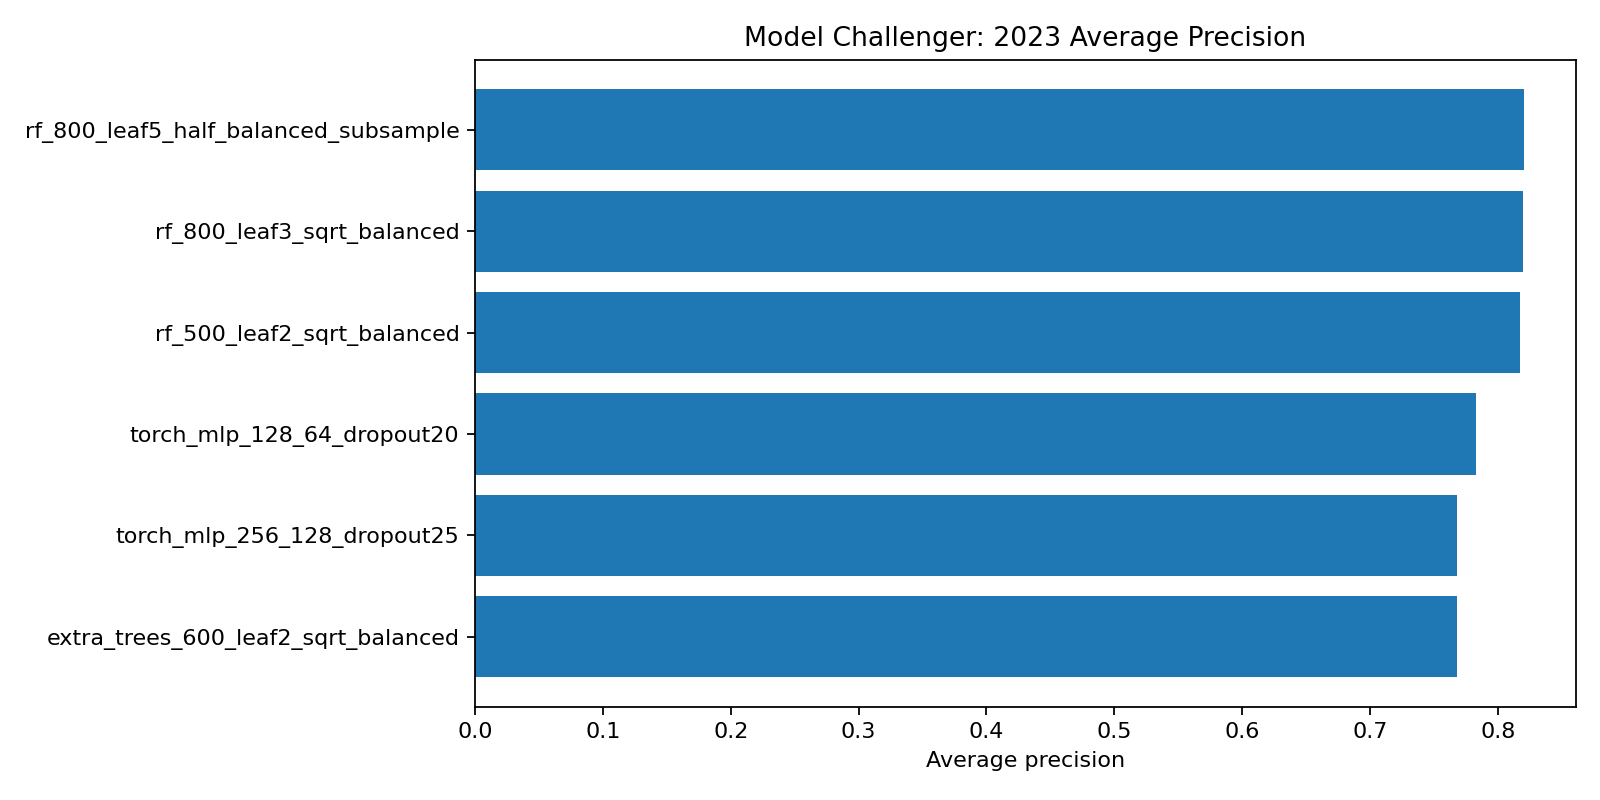

Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/model_challenger_f1.png


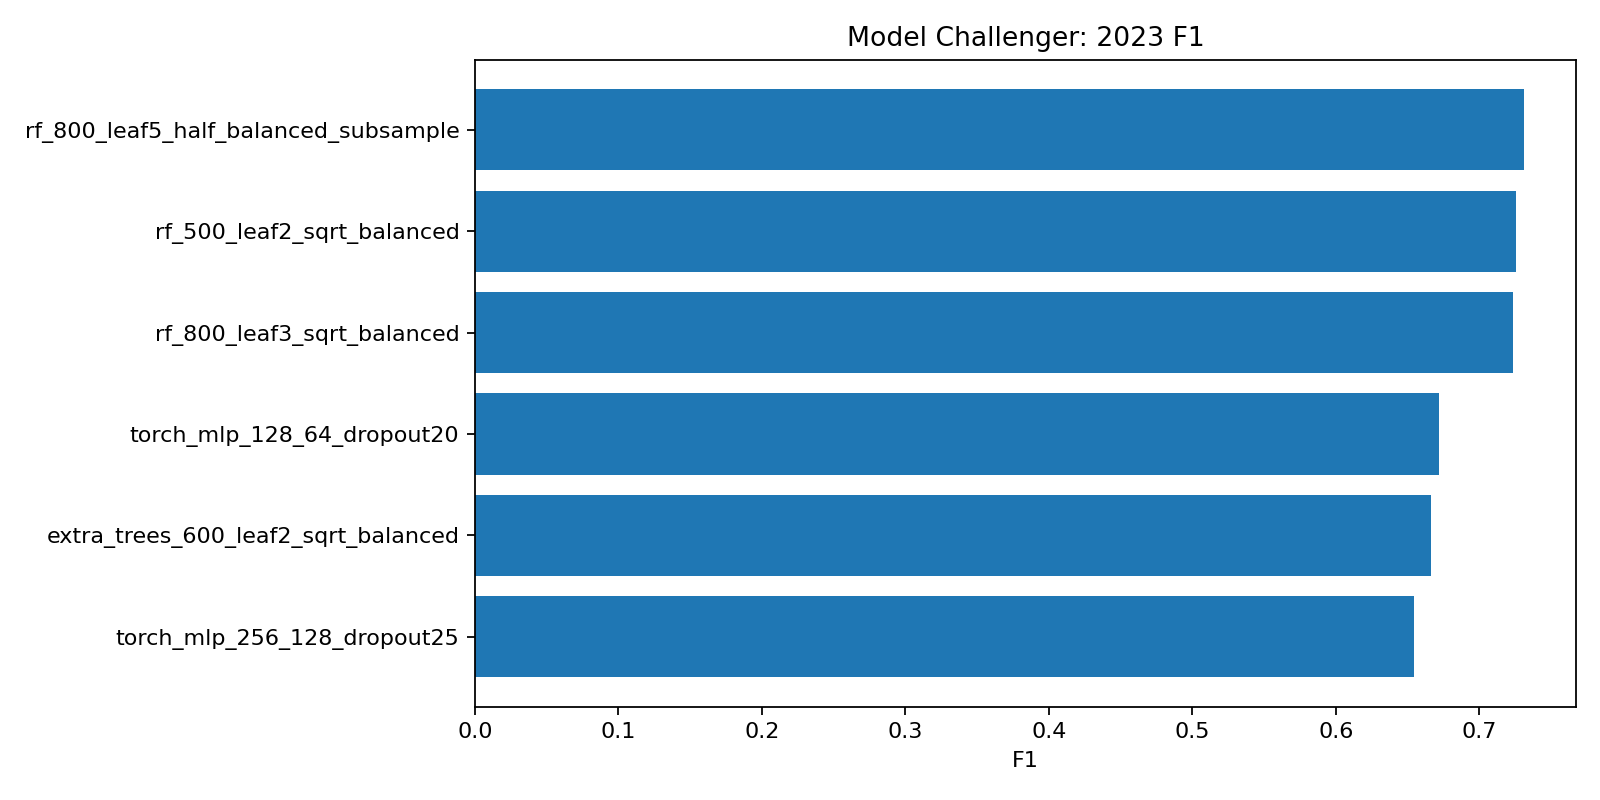

Chart: /content/drive/MyDrive/ibm_project_stuff/MDCE/outputs/charts/model_challenger_torch_training_history.png


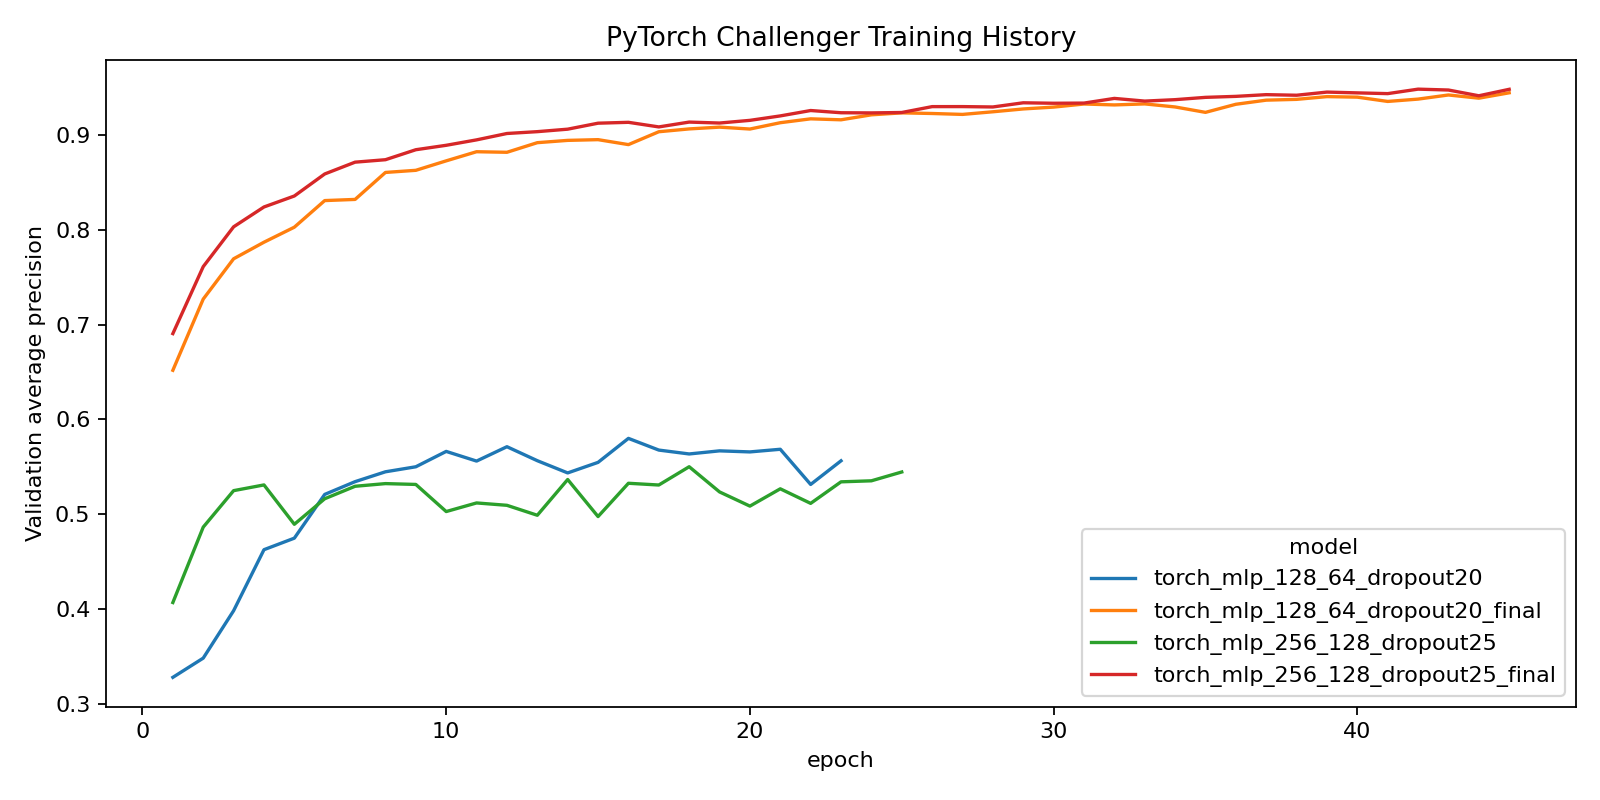

In [5]:
from pathlib import Path
from IPython.display import Markdown, Image, display
import pandas as pd

ROOT = Path('/content/drive/MyDrive/ibm_project_stuff/MDCE')
REPORT_DIR = ROOT / 'outputs' / 'reports'
CHART_DIR = ROOT / 'outputs' / 'charts'
MODEL_DIR = ROOT / 'outputs' / 'models'

for path in [
    MODEL_DIR / 'pit_window_challenger_best_model.joblib',
    MODEL_DIR / 'pit_window_challenger_best_model.pt',
]:
    print(path, path.exists())

report = REPORT_DIR / 'model_challenger_report.md'
if report.exists():
    display(Markdown(report.read_text(encoding='utf-8')))

for csv_name in [
    'model_challenger_leaderboard.csv',
    'model_challenger_threshold_sweeps.csv',
    'model_challenger_torch_training_history.csv',
]:
    path = REPORT_DIR / csv_name
    if path.exists():
        print('', csv_name)
        display(pd.read_csv(path).head(30))

for chart_name in [
    'model_challenger_average_precision.png',
    'model_challenger_f1.png',
    'model_challenger_torch_training_history.png',
]:
    path = CHART_DIR / chart_name
    if path.exists():
        print('Chart:', path)
        display(Image(filename=str(path)))
